# Tarang Pay: volume doubled, revenue didn't. Where should October's one sprint go?

**Payments operations analysis for a payment gateway · Python (pandas, matplotlib) · no machine learning**

The company and data are fictional, and the business rules in the brief are treated as true.

## Business problem
The payments operations team noticed that payment volume nearly doubled this year, from ₹8.9 crore to ₹17 crore a month, but fee revenue grew only by a third. At the same time, numbers that didn't match between systems (reconciliation differences), a spike in refunds and late payouts to merchants made leadership unsure which figures to trust before the investor update.

Tarang Pay helps Indian online businesses accept UPI, card, netbanking and wallet payments. It keeps a fee (0% on UPI) and pays the rest to the merchant the next working day.

## Main business question
> **Payment volume doubled this year, but revenue didn't. Which one fix should get October's engineering sprint?**

Engineering can give payments operations only one sprint in October, so the analysis has to end in one choice, with rupees attached.

**Answer: fix the Growth-plan card pricing.** Most of the gap between volume and revenue is healthy (UPI, which earns nothing, grew from 57% to 67% of payments), and part is a planned price cut. But 85 merchants have been billed ₹0 on cards since 1 May: ₹1.69 lakh lost so far and about ₹42,000 more every month. It's the only problem that loses money every month, is measured exactly, and is cheap to fix.

## Supporting questions
1. Can the data be trusted, file by file and across files?
2. How is the business really doing, and what does the current monthly report get wrong?
3. Where do payments fail, and which failures can Tarang Pay fix?
4. Where does money go missing between payment, payout and finance's books?
5. Which merchants matter most, and do they stay?

## Key findings
1. **Data:** four findings. 184 payments (₹4.8 lakh) were paid out while recorded as failed; card fees were billed at ₹0 for 85 merchants since 1 May; three days of fees (₹74,910) never reached finance's books. The August refund spike looks like an error but is real sale returns.
2. **Performance:** TPV grew from ₹8.9 crore in January to ₹17 crore a month by July. The true success rate is 93.3% of orders; the monthly report shows 88.7% because it counts every retry as a failure.
3. **Failures:** 61% are the customer's choice. The fixable ones cluster at Konkan Bank netbanking in the evening (40% fail, against 18% elsewhere) and at 42 merchants with broken checkouts.
4. **Missing money:** card fees not charged come to ₹1.69 lakh since May, about ₹42,000 a month (5.9% of fee revenue). Since May, Nilgiri Bank's late status updates delay about ₹45 lakh of payouts a month.
5. **Merchants:** the top 10% bring 83% of TPV. Merchants whose checkout fails often in their first month are less likely to be active three months later (70% vs 91%).

**Headline number:** ₹1.69 lakh of card fees not charged since 1 May.

## Contents
| Part | Topic |
|---|---|
| 1 | Data validation |
| 2 | Business performance |
| 3 | Where the money goes missing |
| 4 | Merchants |
| 5 | One engineering sprint |
| 6 | One chart for the Head of Payments |
| 7 | AI usage (`AI_USAGE.md`) |

The notebook reruns top to bottom from the files in `../data/`.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mt, json, os
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
DATA, CHARTS = "../data/", "../charts"; os.makedirs(CHARTS, exist_ok=True)
END = pd.Timestamp("2026-08-31")
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
                     "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left"})
TEAL, RED, GREY, AMBER, INK = "#0F766E", "#D9534F", "#A3ABB5", "#E0A13A", "#1B1F24"
inr = lambda v: f"₹{v:,.0f}"

tx   = pd.read_csv(DATA + "transactions.csv.gz", parse_dates=["created_at", "status_updated_at"])
st   = pd.read_csv(DATA + "settlements.csv.gz", parse_dates=["settlement_date"])
led  = pd.read_csv(DATA + "revenue_ledger.csv.gz", parse_dates=["booked_date"])
ref  = pd.read_csv(DATA + "refunds.csv", parse_dates=["refund_date"])
mer  = pd.read_csv(DATA + "merchants.csv", parse_dates=["joined_date", "kyc_hold_since"])
pri  = pd.read_csv(DATA + "pricing.csv", parse_dates=["valid_from", "valid_to"])
cal  = pd.read_csv(DATA + "calendar.csv", parse_dates=["date"])
rep  = pd.read_csv(DATA + "monthly_report.csv")
for name, d in [("transactions", tx), ("settlements", st), ("revenue_ledger", led), ("refunds", ref),
                ("merchants", mer), ("pricing", pri), ("calendar", cal), ("monthly_report", rep)]:
    print(f"{name:15s} {d.shape[0]:>8,} rows × {d.shape[1]} columns")

transactions     506,062 rows × 11 columns
settlements      445,917 rows × 8 columns
revenue_ledger    72,876 rows × 5 columns
refunds           13,013 rows × 5 columns
merchants          2,010 rows × 7 columns
pricing           11,840 rows × 6 columns
calendar             243 rows × 4 columns
monthly_report         8 rows × 10 columns


## Part 1 · Data validation
### 1.1 Each file on its own
Every check is a line in one table: the rule, and how many rows break it. A clean file shows 0 everywhere.

In [2]:
def check(file, rule, broken):
    return {"file": file, "rule": rule, "rows breaking it": int(broken.sum()) if hasattr(broken, "sum") else int(broken)}
single = [
    check("transactions", "txn_id is unique", tx.txn_id.duplicated()),
    check("transactions", "(order_id, attempt_no) is unique", tx.duplicated(["order_id", "attempt_no"])),
    check("transactions", "amount is positive", tx.amount <= 0),
    check("transactions", "status is success / failed / pending", ~tx.status.isin(["success", "failed", "pending"])),
    check("transactions", "failed rows have a failure reason", (tx.status == "failed") & tx.failure_reason.isna()),
    check("transactions", "non-failed rows have no failure reason", (tx.status != "failed") & tx.failure_reason.notna()),
    check("transactions", "status time is after creation", tx.status_updated_at < tx.created_at),
    check("transactions", "pending rows have no status time", (tx.status == "pending") & tx.status_updated_at.notna()),
    check("transactions", "attempt numbers run 1, 2, 3 with no gaps",
          tx.groupby("order_id").attempt_no.transform(lambda s: s.max() != len(s))),
    check("transactions", "at most one successful attempt per order",
          tx[tx.status == "success"].order_id.duplicated()),
    check("transactions", "created inside 1 Jan – 31 Aug 2026", ~tx.created_at.between("2026-01-01", "2026-08-31 23:59:59")),
    check("settlements", "txn_id is unique", st.txn_id.duplicated()),
    check("settlements", "GST = 18% of fee", (st.gst_charged - (st.fee_charged * .18).round(2)).abs() > .02),
    check("settlements", "settled = payment − fee − GST", (st.settled_amount - (st.payment_amount - st.fee_charged - st.gst_charged)).abs() > .02),
    check("settlements", "settlement date is a working day", ~st.settlement_date.isin(cal.date[cal.is_working_day])),
    check("revenue_ledger", "settlement_id is unique", led.settlement_id.duplicated()),
    check("refunds", "refund_id is unique", ref.refund_id.duplicated()),
    check("refunds", "refund amount is positive", ref.refund_amount <= 0),
    check("merchants", "merchant_id is unique", mer.merchant_id.duplicated()),
    check("merchants", "on_hold merchants have a hold date", (mer.kyc_status == "on_hold") & mer.kyc_hold_since.isna()),
    check("pricing", "rates between 0% and 3%", ~pri.fee_rate_pct.between(0, 3)),
    check("pricing", "UPI is always 0%", (pri.method == "UPI") & (pri.fee_rate_pct != 0)),
    check("pricing", "no overlapping periods for a merchant and method",
          pri.sort_values("valid_from").groupby(["merchant_id", "method"]).apply(
              lambda g: (g.valid_from.iloc[1:].values <= g.valid_to.fillna(END).iloc[:-1].values).sum(), include_groups=False)),
]
pd.DataFrame(single)

,file,rule,rows breaking it
0,transactions,txn_id is unique,0
1,transactions,"(order_id, attempt_no) is unique",0
2,transactions,amount is positive,0
3,transactions,status is success / failed / pending,0
4,transactions,failed rows have a failure reason,0
5,transactions,non-failed rows have no failure reason,0
6,transactions,status time is after creation,0
7,transactions,pending rows have no status time,0
8,transactions,"attempt numbers run 1, 2, 3 with no gaps",0
9,transactions,at most one successful attempt per order,0


Every single-file rule passes. Two things are worth knowing before going further:

In [3]:
print("pending attempts:", (tx.status == "pending").sum(), "| earliest:", tx.loc[tx.status == "pending", "created_at"].min())
print("merchants on KYC hold:", (mer.kyc_status == "on_hold").sum())

pending attempts: 97 | earliest: 2026-08-30 19:37:45
merchants on KYC hold: 38


The 97 pending attempts all started in the last two days of August, so they're simply waiting for a status, which the rules allow for up to 48 hours. The 38 KYC holds are allowed too; their effect is covered in Part 3.

### 1.2 Across files
The files only have to agree in specific ways, so each check follows one business rule from the project brief. The pricing join is the one to be careful with: a merchant can have two rates for the same method (before and after a plan change), so joining on merchant and method alone would duplicate payments. The join below keeps only the rate valid on the payment date, and the row count proves it.

In [4]:
T = tx.set_index("txn_id")
s = st.join(T[["order_id", "created_at", "method", "bank", "status", "failure_reason", "status_updated_at"]], on="txn_id")
s["pay_date"] = s.created_at.dt.normalize()
p = pri.assign(valid_to=pri.valid_to.fillna(pd.Timestamp("2099-12-31")))
sp = s.merge(p, on=["merchant_id", "method"], how="left")
sp = sp[(sp.pay_date >= sp.valid_from) & (sp.pay_date <= sp.valid_to)]
assert len(sp) == len(st), "the pricing join changed the number of rows"
sp["expected_fee"] = (sp.payment_amount * sp.fee_rate_pct / 100).round(2)
sp["fee_gap"] = sp.expected_fee - sp.fee_charged

batch = st.groupby(["settlement_id", "merchant_id", "settlement_date"], as_index=False).fee_charged.sum()
bl = batch.merge(led, on="settlement_id", how="left", suffixes=("", "_led"))
r = ref.join(T[["status", "amount", "created_at"]], on="txn_id")

cross = [
    check("settlements × transactions", "every paid-out payment exists in transactions", s.status.isna()),
    check("settlements × transactions", "every paid-out payment has status success", s.status.notna() & (s.status != "success")),
    check("settlements × pricing", "fee charged = amount × agreed rate", sp.fee_gap.abs() > .02),
    check("settlements × ledger", "every settlement batch has a ledger entry", bl.ledger_id.isna()),
    check("settlements × ledger", "ledger fee = sum of fees in the batch", (bl.fee_booked - bl.fee_charged).abs() > .02),
    check("refunds × transactions", "every refund belongs to a successful payment", r.status != "success"),
    check("refunds × transactions", "refund is not larger than the payment", r.refund_amount > r.amount),
    check("refunds × transactions", "refund is within 90 days of the payment", (r.refund_date - r.created_at.dt.normalize()).dt.days > 90),
    check("refunds × transactions", "refund is not before the payment", r.refund_date < r.created_at.dt.normalize()),
]
pd.DataFrame(cross)

,file,rule,rows breaking it
0,settlements × transactions,every paid-out payment exists in transactions,0
1,settlements × transactions,every paid-out payment has status success,184
2,settlements × pricing,fee charged = amount × agreed rate,3937
3,settlements × ledger,every settlement batch has a ledger entry,1177
4,settlements × ledger,ledger fee = sum of fees in the batch,0
5,refunds × transactions,every refund belongs to a successful payment,0
6,refunds × transactions,refund is not larger than the payment,0
7,refunds × transactions,refund is within 90 days of the payment,0
8,refunds × transactions,refund is not before the payment,0


Three cross-file rules fail. Each gets a closer look.

### 1.3 Paid out, but recorded as failed

In [5]:
fbs = s[s.status == "failed"]
print(f"{len(fbs)} payments, {inr(fbs.payment_amount.sum())} paid out to {fbs.merchant_id.nunique()} merchants")
print("failure reason:", fbs.failure_reason.value_counts().to_dict())
print("created between", fbs.created_at.min(), "and", fbs.created_at.max())
to = tx[(tx.failure_reason == "bank_timeout")].copy()
to["paid_out_anyway"] = to.txn_id.isin(fbs.txn_id)
wk = to.groupby(to.created_at.dt.to_period("W")).paid_out_anyway.mean()
print("\nshare of bank_timeout failures that were paid out anyway, by week:")
print((100 * wk[wk > 0]).round(1).to_string())

184 payments, ₹476,792 paid out to 88 merchants
failure reason: {'bank_timeout': 184}
created between 2026-07-01 09:37:19 and 2026-07-24 12:33:05

share of bank_timeout failures that were paid out anyway, by week:
created_at
2026-06-29/2026-07-05   19.60
2026-07-06/2026-07-12   23.60
2026-07-13/2026-07-19   22.90
2026-07-20/2026-07-26   14.10
Freq: W-SUN


Every one of them failed with `bank_timeout`, every one was created between 1 and 24 July, and they're spread across banks. Before and after that window, no timeout was ever paid out. The pattern fits a change on **Tarang Pay's** side: for about three weeks, the system stopped waiting for slow bank confirmations and recorded a timeout, while the bank captured the money anyway. The settlement system reads the bank's file, so it paid the merchant.

**Handling: flagged but kept, and counted as successful in the analysis.** The money moved, the merchant was paid, and the customer was charged, so treating these as failed would understate TPV and success rate. The source file `transactions.csv` is not changed: engineering has to confirm the cause, and it matters to customers. If a customer saw "payment failed" and paid again with another method, they were charged twice.

### 1.4 Fees that don't match the pricing table

In [6]:
fee_bad = sp[sp.fee_gap.abs() > .02]
print(f"{len(fee_bad):,} payments | {inr(fee_bad.fee_gap.sum())} of fees not charged | {fee_bad.merchant_id.nunique()} merchants")
print("methods:", fee_bad.method.value_counts().to_dict(), "| plan:", fee_bad.plan.value_counts().to_dict())
print("fee charged on these rows:", fee_bad.fee_charged.unique()[:5], "| first date:", fee_bad.pay_date.min().date())
growth = sp[(sp.plan == "Growth") & sp.method.isin(["Credit card", "Debit card"])]
g_m = growth.groupby("merchant_id").fee_charged.sum()
print(f"Growth-plan merchants with card payments: {g_m.size} | charged nothing on cards: {(g_m == 0).sum()}")

3,937 payments | ₹168,853 of fees not charged | 85 merchants
methods: {'Credit card': 2294, 'Debit card': 1643} | plan: {'Growth': 3937}
fee charged on these rows: [0.] | first date: 2026-05-01
Growth-plan merchants with card payments: 185 | charged nothing on cards: 85


All mismatches share three things: they're **card** payments, from merchants on the **Growth plan** that started on **1 May**, and they were charged **exactly ₹0**. Netbanking and wallet payments from the same merchants were charged correctly. So this is a billing configuration error for card rates on part of the Growth plan, not a rounding issue.

**Handling: left alone in the data, reported as potential leakage.** The fees in `settlements` are what was actually charged, so they stay as they are for revenue. The gap between expected and charged is reported separately in Part 3. It's "potential" because some of these merchants might have been promised 0% on cards by sales; finance and sales have to confirm before anyone asks merchants for money.

### 1.5 Settlement batches missing from finance's books

In [7]:
miss = bl[bl.ledger_id.isna()]
print(f"{len(miss):,} batches | {inr(miss.fee_charged.sum())} of fees | dates:", sorted(miss.settlement_date.dt.date.unique()))
print("batches on those dates that did reach the ledger:",
      bl[bl.settlement_date.isin(miss.settlement_date.unique()) & bl.ledger_id.notna()].shape[0])

1,177 batches | ₹74,910 of fees | dates: [datetime.date(2026, 6, 16), datetime.date(2026, 6, 17), datetime.date(2026, 6, 18)]
batches on those dates that did reach the ledger: 0


Every settlement batch from 16, 17 and 18 June is missing from the ledger, and nothing else is. That looks like the daily booking job failing for three days. **Handling: flagged, not corrected.** The amount that should have been booked (₹74,910) can be calculated, but finance's books are finance's to fix. The gap is reported, and the analysis uses settlement fees for revenue.

### 1.6 Looks wrong, but isn't: the August refund spike

In [8]:
cat = mer.set_index("merchant_id").category
ec_sales = tx[(tx.status == "success") & (tx.merchant_id.map(cat) == "E-commerce")]
ec_ref = r[r.index.isin(ref.index)].assign(cat=ref.merchant_id.map(cat))
ec_ref = ec_ref[ec_ref.cat == "E-commerce"]
weekly = pd.DataFrame({"e-commerce sales": ec_sales.groupby(ec_sales.created_at.dt.to_period("W")).amount.sum(),
                       "refunds booked": ec_ref.groupby(ec_ref.refund_date.dt.to_period("W")).refund_amount.sum()}).loc["2026-07-20":]
weekly

,e-commerce sales,refunds booked
2026-07-20/2026-07-26,"7,073,131.00","284,116.00"
2026-07-27/2026-08-02,"6,911,185.00","269,777.00"
2026-08-03/2026-08-09,"14,265,746.00","262,850.00"
2026-08-10/2026-08-16,"7,482,685.00","211,237.00"
2026-08-17/2026-08-23,"5,172,047.00","192,667.00"
2026-08-24/2026-08-30,"5,302,730.00","1,860,297.00"
2026-08-31/2026-09-06,"695,682.00","24,422.00"


In [9]:
spike = ec_ref[ec_ref.refund_date.between("2026-08-24", "2026-08-30")]
print(f"{len(spike):,} refunds, {inr(spike.refund_amount.sum())} in the week of 24 Aug")
print("they refund payments made on:", spike.created_at.dt.date.value_counts().head(5).to_dict())
print("all within the 90-day window, none above the payment:", (spike.refund_amount <= spike.amount).all())

1,663 refunds, ₹1,860,297 in the week of 24 Aug
they refund payments made on: {datetime.date(2026, 8, 9): 405, datetime.date(2026, 8, 8): 377, datetime.date(2026, 8, 7): 346, datetime.date(2026, 8, 10): 342, datetime.date(2026, 8, 16): 13}
all within the 90-day window, none above the payment: True


E-commerce refunds jumped about 8× in the week of 24 August. But almost all of them refund payments made on 7–10 August, the days of the Independence Day sale, when e-commerce sales were twice their normal level. Each refund belongs to a real successful payment, is no larger than it, and falls well inside 90 days. This is a batch of sale returns being processed together, which is normal. **Handling: left alone.** The monthly report should show refunds by the month of the original payment, so a sale month's returns sit next to that sale.

**The KYC holds** are the second thing that looks wrong but isn't: successful payments from 38 merchants were never paid out. The rules say that's correct. They're counted in Part 3.

### 1.7 Investigation log

In [10]:
log = pd.DataFrame([
    ["Paid out, but recorded as failed", f"{len(fbs)} payments · {inr(fbs.payment_amount.sum())}",
     "A timeout change on our side (1–24 Jul) marked slow bank approvals as failed; the bank captured the money",
     "Flagged but kept; counted as successful", "Money moved and the merchant was paid; the source record is engineering's to fix"],
    ["Card fees of ₹0 for Growth-plan merchants", f"{len(fee_bad):,} payments · {inr(fee_bad.fee_gap.sum())} not charged",
     "Billing set card rates to 0% for part of the 1 May Growth-plan migration",
     "Left alone; reported as potential leakage", "Fees charged are the fact; whether they were promised is for sales and finance to confirm"],
    ["Settlement batches missing from the ledger", f"{len(miss):,} batches · {inr(miss.fee_charged.sum())} of fees",
     "Finance's daily booking job didn't run on 16–18 June", "Flagged", "Finance owns the books; the correct amount is known"],
    ["Refund spike, week of 24 Aug", f"{len(spike):,} refunds · {inr(spike.refund_amount.sum())}",
     "Returns from the 7–10 Aug sale processed together", "Left alone", "Every refund is valid; it's a timing effect"],
    ["Successful payments never paid out", "see Part 3", "38 merchants on KYC hold", "Left alone", "Correct behaviour under the rules"],
    ["97 pending attempts", "97 attempts", "Started on 30–31 Aug; statuses not in yet", "Excluded from rates", "Within the 48-hour window"],
], columns=["what I noticed", "rows and ₹", "what I think happened", "handling", "why"])
log

,what I noticed,rows and ₹,what I think happened,handling,why
0,"Paid out, but recorded as failed","184 payments · ₹476,792",A timeout change on our side (1–24 Jul) marked...,Flagged but kept; counted as successful,Money moved and the merchant was paid; the sou...
1,Card fees of ₹0 for Growth-plan merchants,"3,937 payments · ₹168,853 not charged",Billing set card rates to 0% for part of the 1...,Left alone; reported as potential leakage,Fees charged are the fact; whether they were p...
2,Settlement batches missing from the ledger,"1,177 batches · ₹74,910 of fees",Finance's daily booking job didn't run on 16–1...,Flagged,Finance owns the books; the correct amount is ...
3,"Refund spike, week of 24 Aug","1,663 refunds · ₹1,860,297",Returns from the 7–10 Aug sale processed together,Left alone,Every refund is valid; it's a timing effect
4,Successful payments never paid out,see Part 3,38 merchants on KYC hold,Left alone,Correct behaviour under the rules
5,97 pending attempts,97 attempts,Started on 30–31 Aug; statuses not in yet,Excluded from rates,Within the 48-hour window


### 1.8 Open questions and assumptions
These questions would need answers from engineering or finance before the numbers are fully trusted. Until then, the analysis uses the assumption in the right-hand column.

| Question | Assumption used in this analysis |
|---|---|
| Did payment timeout handling change around 1 July and roll back on 24 July? Were any customers charged twice? | The bank captured these payments, so they count as successful |
| Were any Growth-plan merchants promised 0% on cards, or is the ₹0 fee a billing error? | The pricing table is the agreement, so the gap is potential leakage |
| Did the ledger booking job fail on 16–18 June? | Yes: settlement fees are used for revenue, and the ledger gap is reported separately |
| Does Nilgiri Bank's status feed have a known delay since May (Part 3)? | The delay is on the bank's side: it affects one bank and starts on one date |
| Can refunds fail or be reversed? | No: the refunds file shows completed refunds only |

## Part 2 · Business performance
From here on, "successful" includes the payments that were paid out despite being recorded as failed.

In [11]:
tx["ok"] = (tx.status == "success") | tx.txn_id.isin(fbs.txn_id)
tx["month"] = tx.created_at.dt.to_period("M")
done = tx[tx.status != "pending"]
orders = done.groupby("order_id").agg(ok=("ok", "any"), month=("month", "first"), attempts=("attempt_no", "max"))
succ = tx[tx.ok]
fees = st.join(T[["created_at"]], on="txn_id").assign(month=lambda d: d.created_at.dt.to_period("M"))
ref_m = r.assign(month=r.created_at.dt.to_period("M"))                 # refunds by the month of the original payment
monthly = pd.DataFrame({
    "attempts": done.groupby("month").size(),
    "orders": orders.groupby("month").size(),
    "success rate, attempts %": 100 * done.groupby("month").ok.mean(),
    "success rate, orders %": 100 * orders.groupby("month").ok.mean(),
    "TPV ₹ Cr": succ.groupby("month").amount.sum() / 1e7,
    "avg payment ₹": succ.groupby("month").amount.mean(),
    "fee revenue ₹ L": fees.groupby("month").fee_charged.sum() / 1e5,
    "active merchants": succ.groupby("month").merchant_id.nunique(),
})
monthly["take rate %"] = 100 * monthly["fee revenue ₹ L"] * 1e5 / (monthly["TPV ₹ Cr"] * 1e7)
monthly["refund rate % (by payment month)"] = 100 * ref_m.groupby("month").refund_amount.sum() / (monthly["TPV ₹ Cr"] * 1e7)
monthly.index = monthly.index.astype(str)
monthly.round(2)

,attempts,orders,"success rate, attempts %","success rate, orders %",TPV ₹ Cr,avg payment ₹,fee revenue ₹ L,active merchants,take rate %,refund rate % (by payment month)
month,,,,,,,,,,
2026-01,45620,43441,89.00,93.47,8.86,"2,182.93",5.43,882,0.61,2.46
2026-02,44432,42323,88.97,93.40,8.55,"2,162.42",5.15,921,0.60,2.48
2026-03,53724,51069,88.80,93.41,10.36,"2,172.47",5.96,966,0.58,2.83
2026-04,58119,55237,88.88,93.52,11.70,"2,264.61",6.58,1004,0.56,2.34
2026-05,64280,61137,88.73,93.29,12.30,"2,155.74",5.97,1032,0.49,2.35
2026-06,71918,68329,88.50,93.14,15.08,"2,369.84",7.22,1064,0.48,2.21
2026-07,81500,77495,88.70,93.29,17.31,"2,394.95",8.04,1106,0.46,2.41
2026-08,86372,82149,88.64,93.20,17.00,"2,220.92",7.16,1100,0.42,2.05


**Which success rate?** This analysis uses **orders**: 93.3% on average, against 88.7% for attempts. A customer who fails once and pays on the second try is a success for the merchant; counting attempts makes every retry look like a lost payment. The attempt rate still matters for engineering, because each failed attempt is friction. It's just the wrong number for the business.

Fee revenue here is taken from settlements and assigned to the month of the payment, so it's not affected by the missing ledger days. August's refund rate will keep rising: refunds can arrive up to 90 days later, and most of August's haven't happened yet.

### 2.1 Where payments fail

In [12]:
fails = done[~done.ok]
reason = fails.failure_reason.value_counts(normalize=True).mul(100).round(1).rename("% of failed attempts").to_frame()
reason["who can fix it"] = reason.index.map({"customer_dropped": "customer's choice", "insufficient_funds": "customer's choice",
    "bank_declined": "bank (partly)", "bank_timeout": "bank / Tarang Pay", "technical_error": "Tarang Pay / merchant integration"})
reason

,% of failed attempts,who can fix it
failure_reason,,
customer_dropped,43.60,customer's choice
insufficient_funds,17.70,customer's choice
bank_declined,15.60,bank (partly)
technical_error,11.60,Tarang Pay / merchant integration
bank_timeout,11.50,bank / Tarang Pay


In [13]:
done_ = done.assign(hour=done.created_at.dt.hour, failed=~done.ok)
done_["time"] = np.where(done_.hour.between(19, 22), "7–11 pm", "rest of day")
nb = done_[done_.method == "Netbanking"].pivot_table(index="bank", columns="time", values="failed", aggfunc="mean").mul(100).round(1)
nb.sort_values("7–11 pm", ascending=False)

time,7–11 pm,rest of day
bank,,
Konkan Bank,39.90,18.60
Sagar Bank,19.40,17.50
Deccan Bank,19.10,17.40
Himalaya Bank,18.20,18.90
Kaveri Bank,18.10,17.60
Ganga Bank,18.00,18.40
Nilgiri Bank,17.00,17.70
Vardhan Bank,15.80,17.20


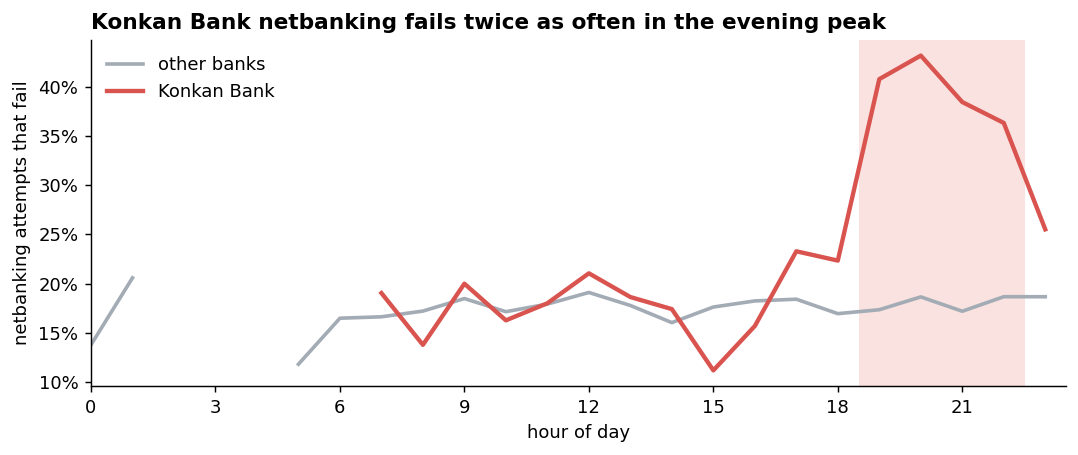

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))
hh = done_[done_.method == "Netbanking"].assign(konkan=lambda d: d.bank == "Konkan Bank").groupby(["hour", "konkan"]).failed.agg(["mean", "size"])
h = (hh["mean"].where(hh["size"] >= 40) * 100).unstack()          # hide hours with too few attempts to read
ax.plot(h.index, h[False], color=GREY, lw=2, label="other banks")
ax.plot(h.index, h[True], color=RED, lw=2.4, label="Konkan Bank")
ax.axvspan(18.5, 22.5, color="#F4C7C3", alpha=.5, lw=0)
ax.set_xlim(5.5, 23.5)
ax.yaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"{v:.0f}%")); ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of day"); ax.set_ylabel("netbanking attempts that fail"); ax.legend(frameon=False)
ax.set_title("Konkan Bank netbanking fails twice as often in the evening peak")
fig.tight_layout(); fig.savefig(f"{CHARTS}/02_konkan_peak_failures.png", bbox_inches="tight"); plt.show()

In [15]:
kp = done_[(done_.bank == "Konkan Bank") & (done_.method == "Netbanking") & (done_.time == "7–11 pm")]
other_rate = done_[(done_.bank != "Konkan Bank") & (done_.method == "Netbanking") & (done_.time == "7–11 pm")].failed.mean()
extra = kp.failed.sum() - other_rate * len(kp)
lost = orders.join(tx.groupby("order_id").agg(bank=("bank", "first"), method=("method", "first"), hour=("created_at", lambda s: s.iloc[0].hour), amount=("amount", "first")))
kp_o = lost[(lost.bank == "Konkan Bank") & (lost.method == "Netbanking") & lost.hour.between(19, 22)]
print(f"extra failed attempts vs other banks: {extra:,.0f} | Konkan peak netbanking orders never completed: {(~kp_o.ok).sum():,} worth {inr(kp_o.loc[~kp_o.ok, 'amount'].sum())}")

extra failed attempts vs other banks: 199 | Konkan peak netbanking orders never completed: 168 worth ₹474,423


In [16]:
te = done.assign(tech=done.failure_reason.eq("technical_error")).groupby("merchant_id").agg(attempts=("tech", "size"), tech_error_pct=("tech", "mean"))
te["tech_error_pct"] *= 100
te = te[te.attempts >= 100]
print(f"merchants with 100+ attempts: {len(te)} | median technical-error rate {te.tech_error_pct.median():.1f}% | "
      f"merchants above 4%: {(te.tech_error_pct > 4).sum()}")
te.sort_values("tech_error_pct", ascending=False).head(8).round(1).join(mer.set_index("merchant_id")[["category", "joined_date"]])

merchants with 100+ attempts: 472 | median technical-error rate 0.8% | merchants above 4%: 42


,attempts,tech_error_pct,category,joined_date
merchant_id,,,,
M11451,102,13.70,Education,2026-01-01
M11871,200,10.50,Food & Restaurants,2026-06-25
M11649,570,9.80,Education,2026-03-25
M11836,133,9.80,Food & Restaurants,2026-06-13
M11894,109,9.20,E-commerce,2026-07-02
M11531,274,9.10,Travel,2026-02-05
M11632,256,9.00,E-commerce,2026-03-19
M11668,313,8.90,Education,2026-03-31


Most failures (61%) are the customer's choice: they gave up or didn't have the money. The fixable ones cluster in two places:
- **Konkan Bank netbanking in the evening:** from 7 to 11 pm, 40% of its netbanking attempts fail, against about 18% for every other bank at the same hour, and against 19% for Konkan itself the rest of the day. Across the eight months, 168 of these orders (₹4.7 lakh) were never completed.
- **Merchants with broken integrations:** the typical merchant sees technical errors on under 1% of attempts; 42 merchants see more than 4%, up to 14%. That's a problem in the merchant's checkout, which Tarang Pay's integrations team can help fix.

### 2.2 What the current monthly report gets wrong

In [17]:
cmp_ = pd.DataFrame({
    "reported success %": rep.set_index("month").success_rate_pct,
    "correct success % (orders)": monthly["success rate, orders %"],
    "reported TPV ₹ Cr": rep.set_index("month").tpv_inr / 1e7,
    "correct TPV ₹ Cr": monthly["TPV ₹ Cr"],
    "reported fee revenue ₹ L": rep.set_index("month").fee_revenue_inr / 1e5,
    "fee charged ₹ L (by payment month)": monthly["fee revenue ₹ L"],
    "reported refund %": rep.set_index("month").refund_rate_pct,
    "refund % by payment month": monthly["refund rate % (by payment month)"],
})
cmp_.round(2)

,reported success %,correct success % (orders),reported TPV ₹ Cr,correct TPV ₹ Cr,reported fee revenue ₹ L,fee charged ₹ L (by payment month),reported refund %,refund % by payment month
month,,,,,,,,
2026-01,89.00,93.47,8.86,8.86,5.26,5.43,1.23,2.46
2026-02,89.00,93.40,8.55,8.55,4.94,5.15,2.42,2.48
2026-03,88.80,93.41,10.36,10.36,6.15,5.96,2.51,2.83
2026-04,88.90,93.52,11.70,11.70,6.55,6.58,2.51,2.34
2026-05,88.70,93.29,12.30,12.30,5.80,5.97,2.23,2.35
2026-06,88.50,93.14,15.08,15.08,6.61,7.22,2.12,2.21
2026-07,88.50,93.29,17.27,17.31,8.04,8.04,2.13,2.41
2026-08,88.50,93.20,17.00,17.00,7.43,7.16,3.27,2.05


In [18]:
jun_gap = (rep.set_index("month").fee_revenue_inr["2026-06"] - led[led.booked_date.dt.month == 6].fee_booked.sum())
tpv_gap = (monthly["TPV ₹ Cr"] - rep.set_index("month").tpv_inr / 1e7) * 1e7
print("TPV understated by:", {k: inr(v) for k, v in tpv_gap[tpv_gap > 1].items()})
print("June fee revenue in the report vs ledger with the missing days restored:",
      inr(rep.set_index("month").fee_revenue_inr["2026-06"]), "vs", inr(rep.set_index("month").fee_revenue_inr["2026-06"] + miss.fee_charged.sum()))

TPV understated by: {'2026-07': '₹476,792'}
June fee revenue in the report vs ledger with the missing days restored: ₹660,995 vs ₹735,905


| Reported number | Problem | Size |
|---|---|---|
| **Success rate** | Counts attempts, so every retry looks like a lost payment | Understates by 4.6 points every month (88.7% vs 93.3%) |
| **TPV (July)** | Leaves out the payments recorded as failed but paid out | ₹4.8 lakh too low |
| **Fee revenue (June)** | Comes from the ledger, which is missing 16–18 June | ₹74,910 too low (about 10%) |
| **Fee revenue (May–Aug)** | Correct for what was charged, but hides the ₹0 card fees | Not wrong, but ₹1.69 lakh below what pricing says |
| **Refund rate** | Divides refunds booked in a month by that month's sales | Makes August look like a spike; understates recent months, whose refunds haven't arrived yet |
| **Take rate** | Inherits the June revenue gap | June too low |

### 2.3 Take rate fell. Is that bad news?

In [19]:
f2 = fees.join(T[["method"]], on="txn_id").join(pri.drop_duplicates(["merchant_id"]).set_index("merchant_id")[[]], on="merchant_id")
tr = f2.groupby("month").apply(lambda d: pd.Series({
    "UPI share of TPV %": 100 * d.payment_amount[d.method == "UPI"].sum() / d.payment_amount.sum(),
    "take rate, all %": 100 * d.fee_charged.sum() / d.payment_amount.sum(),
    "take rate on non-UPI %": 100 * d.fee_charged[d.method != "UPI"].sum() / d.payment_amount[d.method != "UPI"].sum()}), include_groups=False)
exp = sp.assign(month=sp.created_at.dt.to_period("M")).groupby("month").apply(
    lambda d: 100 * d.expected_fee[d.method != "UPI"].sum() / d.payment_amount[d.method != "UPI"].sum(), include_groups=False).rename("non-UPI, if billed correctly %")
tr = tr.join(exp); tr.index = tr.index.astype(str); tr.round(3)

,UPI share of TPV %,"take rate, all %",take rate on non-UPI %,"non-UPI, if billed correctly %"
month,,,,
2026-01,56.80,0.61,1.42,1.42
2026-02,57.84,0.60,1.43,1.43
2026-03,59.86,0.57,1.43,1.43
2026-04,61.02,0.56,1.44,1.44
2026-05,63.17,0.49,1.32,1.40
2026-06,63.93,0.48,1.33,1.41
2026-07,65.14,0.47,1.34,1.42
2026-08,67.29,0.44,1.34,1.41


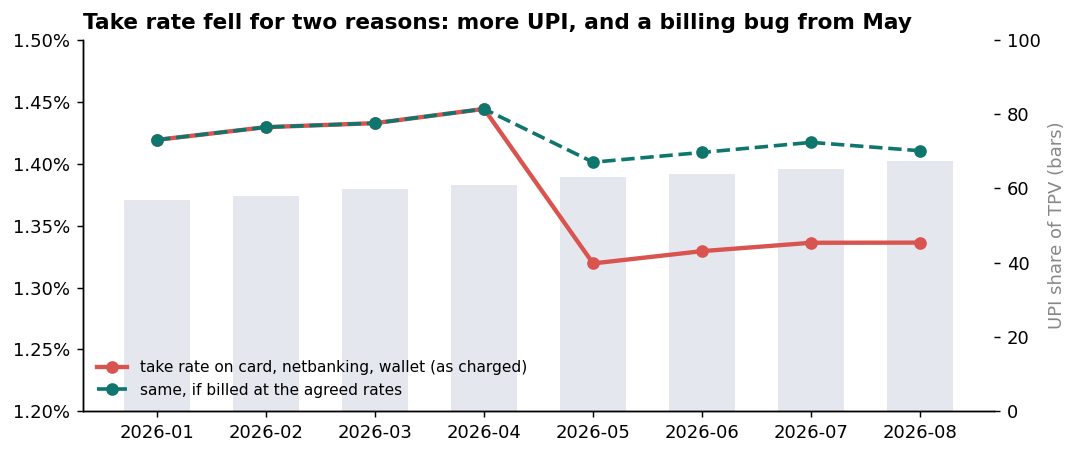

In [20]:
fig, ax = plt.subplots(figsize=(8.4, 3.6))
x = tr.index
ax.plot(x, tr["take rate on non-UPI %"], color=RED, lw=2.4, marker="o", label="take rate on card, netbanking, wallet (as charged)")
ax.plot(x, tr["non-UPI, if billed correctly %"], color=TEAL, lw=2, ls="--", marker="o", label="same, if billed at the agreed rates")
ax2 = ax.twinx(); ax2.bar(x, tr["UPI share of TPV %"], color="#E4E8EE", zorder=0, width=.6)
ax2.set_ylim(0, 100); ax2.set_ylabel("UPI share of TPV (bars)", color="#888"); ax2.spines["top"].set_visible(False)
ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_ylim(1.2, 1.5); ax.yaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax.legend(frameon=False, loc="lower left", fontsize=8.5)
ax.set_title("Take rate fell for two reasons: more UPI, and a billing bug from May")
fig.tight_layout(); fig.savefig(f"{CHARTS}/03_take_rate.png", bbox_inches="tight"); plt.show()

Mostly no. Take rate fell from 0.61% to 0.44% mainly because UPI grew from 57% to 67% of TPV, and UPI earns 0%, so that part is growth, not a problem. But the rate on card, netbanking and wallet payments also dropped in May, from 1.44% to 1.33%, and about three-quarters of that drop is the ₹0 card-fee bug; the rest is the Growth plan's intended lower prices.

## Part 3 · Where the money goes missing
### 3.1 The chain, month by month

In [21]:
wd = np.array(sorted(cal.date[cal.is_working_day]), dtype="datetime64[ns]")
wd_ext = np.concatenate([wd, np.array(pd.bdate_range("2026-09-01", periods=10), dtype="datetime64[ns]")])
def next_working_day(d):
    return pd.to_datetime(wd_ext[np.searchsorted(wd_ext, np.asarray(d, dtype="datetime64[ns]"), side="right")])

sc = succ[["txn_id", "merchant_id", "created_at", "status_updated_at", "amount", "bank", "method", "month"]].copy()
sc["promised"] = next_working_day(sc.created_at.dt.normalize())
sc = sc.merge(st[["txn_id", "settlement_date"]], on="txn_id", how="left")
sc["paid_out"] = sc.settlement_date.notna()
sc["on_time"] = sc.settlement_date == sc.promised
sd_ = sc.status_updated_at.fillna(sc.created_at)
sc["rule_due"] = next_working_day(np.where(sd_.dt.hour >= 23, sd_.dt.normalize() + pd.Timedelta(days=1), sd_.dt.normalize()))
# only payments whose payout date had arrived by 31 Aug can be judged; the rest aren't late, they're not due yet
due = sc[(sc.promised <= END) & (sc.rule_due <= END)]
chain = due.groupby("month").agg(successful=("txn_id", "size"), paid_out=("paid_out", "mean"), on_time=("on_time", "mean"))
chain[["paid_out", "on_time"]] *= 100
chain.columns = ["successful payments due by 31 Aug", "settlement completion %", "on-time settlement %"]
chain.index = chain.index.astype(str); chain.round(2)

,successful payments due by 31 Aug,settlement completion %,on-time settlement %
month,,,
2026-01,40604,100.00,97.52
2026-02,39529,100.00,97.13
2026-03,47706,100.00,97.37
2026-04,51654,100.00,97.59
2026-05,57035,99.93,94.36
2026-06,63645,99.84,94.32
2026-07,72292,99.66,93.99
2026-08,74190,99.53,94.64


Only payments whose payout date had arrived by 31 August are counted; the rest aren't late, they're not due yet. Settlement completion stays above 99.5% every month, but **on-time settlement fell from about 97.4% to about 94.3% in May** and stayed there. Something changed in May.

### 3.2 Why payments were paid out late

In [22]:
late = due[due.paid_out & ~due.on_time].copy()
sd = late.status_updated_at.fillna(late.created_at)
late["status_day"] = np.where(sd.dt.hour >= 23, sd.dt.normalize() + pd.Timedelta(days=1), sd.dt.normalize())
late["status_delay_h"] = (late.status_updated_at - late.created_at).dt.total_seconds() / 3600
late["cause"] = np.select(
    [late.bank.eq("Nilgiri Bank") & (late.status_delay_h > 2),
     late.status_day > late.created_at.dt.normalize()],
    ["Nilgiri Bank sent the success status hours late", "Payment or status after the 23:00 cut-off"], "other")
late.groupby("cause").agg(payments=("txn_id", "size"), value=("amount", "sum"), merchants=("merchant_id", "nunique")).assign(
    **{"value ₹ L": lambda d: d.value / 1e5}).drop(columns="value").round(1)

,payments,merchants,value ₹ L
cause,,,
Nilgiri Bank sent the success status hours late,7781,773,180.20
Payment or status after the 23:00 cut-off,11253,932,252.30
other,17,17,0.60


In [23]:
nil = due[due.created_at >= "2026-05-01"].assign(slow=lambda d: (d.status_updated_at - d.created_at).dt.total_seconds() > 7200)
bank_late = nil.groupby("bank").agg(late_pct=("on_time", lambda s: 100 * (1 - s.mean())), slow_status_pct=("slow", lambda s: 100 * s.mean()))
nb_month = due[due.bank == "Nilgiri Bank"].groupby("month").on_time.apply(lambda s: 100 * (1 - s.mean()))
print(bank_late.round(1).sort_values("late_pct", ascending=False).to_string())
print("\nNilgiri Bank, % paid out late by month:", nb_month.round(1).to_dict())
nil_late = late[late.cause.str.startswith("Nilgiri")]
per_month = nil_late.groupby("month").amount.sum()
print("Nilgiri-caused late payouts per month (May–Aug avg):", inr(per_month.loc["2026-05":].mean()), "| merchants affected:", nil_late.merchant_id.nunique())

               late_pct  slow_status_pct
bank                                    
Nilgiri Bank      26.30            37.10
Deccan Bank        3.10             0.00
Konkan Bank        3.00             0.00
Vardhan Bank       2.90             0.00
Kaveri Bank        2.80             0.00
Sagar Bank         2.80             0.00
Himalaya Bank      2.70             0.00
Ganga Bank         2.70             0.00

Nilgiri Bank, % paid out late by month: {Period('2026-01', 'M'): 2.4, Period('2026-02', 'M'): 2.9, Period('2026-03', 'M'): 2.1, Period('2026-04', 'M'): 2.0, Period('2026-05', 'M'): 26.5, Period('2026-06', 'M'): 27.0, Period('2026-07', 'M'): 27.2, Period('2026-08', 'M'): 24.6}
Nilgiri-caused late payouts per month (May–Aug avg): ₹4,505,388 | merchants affected: 773


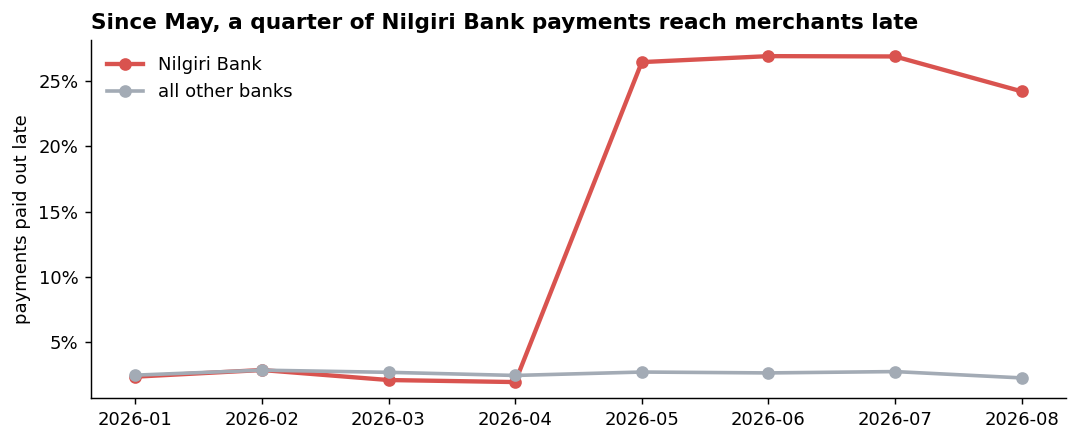

In [24]:
fig, ax = plt.subplots(figsize=(8.4, 3.5))
bm = due[due.paid_out].assign(nilgiri=lambda d: d.bank.eq("Nilgiri Bank")).groupby(["month", "nilgiri"]).on_time.apply(lambda s: 100 * (1 - s.mean())).unstack()
ax.plot(bm.index.astype(str), bm[True], color=RED, lw=2.4, marker="o", label="Nilgiri Bank")
ax.plot(bm.index.astype(str), bm[False], color=GREY, lw=2, marker="o", label="all other banks")
ax.yaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"{v:.0f}%")); ax.set_ylabel("payments paid out late")
ax.legend(frameon=False); ax.set_title("Since May, a quarter of Nilgiri Bank payments reach merchants late")
fig.tight_layout(); fig.savefig(f"{CHARTS}/01_nilgiri_late_settlement.png", bbox_inches="tight"); plt.show()

Two causes, and they need different answers:
- **The 23:00 cut-off** (about 11,250 payments across the whole period, every bank, steady every month) is the rule working as designed. **Expected behaviour.**
- **Nilgiri Bank** is the change in May. Since then, 37% of its successful payments send their final status 3–30 hours late, so about 26% of them miss the cut-off and reach the merchant a working day late, against about 3% for other banks. **Process problem, owner: bank partnerships and the integrations team.** About ₹45 lakh of payouts a month reach 773 merchants late.

### 3.3 Why some payments were never paid out

In [25]:
hold = mer.set_index("merchant_id").kyc_hold_since
np_ = sc[~sc.paid_out].copy()
sd2 = np_.status_updated_at.fillna(np_.created_at)
np_["due"] = next_working_day(np.where(sd2.dt.hour >= 23, sd2.dt.normalize() + pd.Timedelta(days=1), sd2.dt.normalize()))
np_["cause"] = np.select([np_.due > END, np_.merchant_id.map(hold).notna() & (np_.due >= np_.merchant_id.map(hold))],
                         ["Not due yet: payout falls after 31 Aug", "Merchant on KYC hold"], "unexplained")
gap = np_.groupby("cause").agg(payments=("txn_id", "size"), value=("amount", "sum"), merchants=("merchant_id", "nunique"))
gap["value ₹ L"] = gap.value / 1e5; gap.drop(columns="value").round(1)

,payments,merchants,value ₹ L
cause,,,
Merchant on KYC hold,738,26,13.40
Not due yet: payout falls after 31 Aug,2374,430,56.30


Every successful payment that wasn't paid out has an explanation, and neither is an error:
- **Not due yet:** the file ends on 31 August, so payments from its last working day haven't reached their payout date. This is the timing pitfall from the project brief: a same-day comparison would call it a ₹ gap.
- **KYC holds:** 738 payments worth ₹13.4 lakh, from 26 of the 38 merchants on hold. Correct under the rules. **Owner: compliance**, who should say how long these holds usually last, because money waiting on a hold is money merchants are waiting for.

The reverse case, the 184 payments paid out but recorded as failed (Part 1), is a **data problem** with engineering as owner.

### 3.4 Fees: potential leakage

In [26]:
leak = fee_bad.assign(month=fee_bad.pay_date.dt.to_period("M")).groupby("month").agg(
    payments=("txn_id", "size"), merchants=("merchant_id", "nunique"), fees_not_charged=("fee_gap", "sum"))
leak["GST not charged"] = leak.fees_not_charged * .18
leak.index = leak.index.astype(str)
print(f"total fees not charged since 1 May: {inr(leak.fees_not_charged.sum())} | per month: {inr(leak.fees_not_charged.mean())} "
      f"| share of fee revenue May–Aug: {100 * leak.fees_not_charged.sum() / fees[fees.month >= '2026-05'].fee_charged.sum():.1f}%")
leak.round(0)

total fees not charged since 1 May: ₹168,853 | per month: ₹42,213 | share of fee revenue May–Aug: 5.9%


,payments,merchants,fees_not_charged,GST not charged
month,,,,
2026-05,989,85,"36,989.00","6,658.00"
2026-06,1007,81,"43,315.00","7,797.00"
2026-07,1036,75,"48,800.00","8,784.00"
2026-08,905,72,"39,749.00","7,155.00"


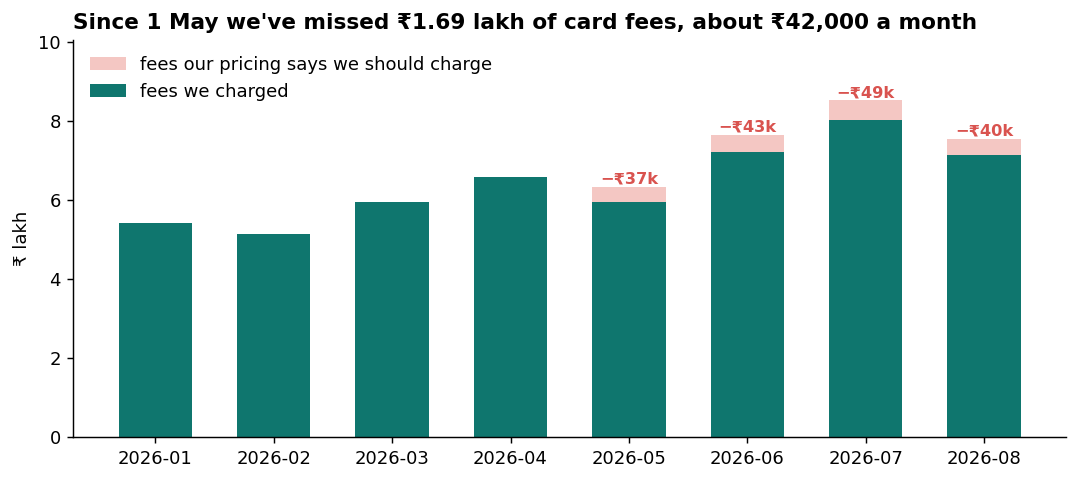

In [27]:
fig, ax = plt.subplots(figsize=(8.4, 3.8))
ex = sp.assign(month=sp.created_at.dt.to_period("M").astype(str)).groupby("month")[["expected_fee", "fee_charged"]].sum() / 1e5
ax.bar(ex.index, ex.expected_fee, color="#F4C7C3", width=.62, label="fees our pricing says we should charge")
ax.bar(ex.index, ex.fee_charged, color=TEAL, width=.62, label="fees we charged")
for i, (e_, c_) in enumerate(ex.values):
    if e_ - c_ > .1: ax.text(i, e_ + .08, f"−₹{(e_ - c_) * 100:,.0f}k", ha="center", fontsize=9, color=RED, fontweight="bold")
ax.set_ylabel("₹ lakh"); ax.set_ylim(0, ex.expected_fee.max() * 1.18); ax.legend(frameon=False, loc="upper left")
ax.set_title(f"Since 1 May we've missed ₹{leak.fees_not_charged.sum() / 1e5:.2f} lakh of card fees, about ₹{leak.fees_not_charged.mean() / 1e3:.0f},000 a month")
fig.tight_layout(); fig.savefig(f"{CHARTS}/00_recommendation.png", bbox_inches="tight"); plt.show()

**Fix the Growth-plan card pricing now: 85 merchants have paid nothing on cards since 1 May, ₹1.69 lakh so far and about ₹42,000 more every month.**

The leak is 5.9% of fee revenue since May, all of it from one cause. It's **potential** leakage until sales confirms these merchants weren't promised 0% on cards; if they weren't, the missed fees are recoverable under the merchant agreement.

### 3.5 Finance's books
The ledger gap (₹74,910, 16–18 June) is a **different** problem from the fee leak. Settlements and ledger agree to the paisa on every batch that was booked, including the ₹0 card fees, so the ledger faithfully records a wrong fee; the fee bug happens before the ledger, in billing. The June gap is a booking job that didn't run.

## Part 4 · Merchants
### 4.1 Concentration

In [28]:
mv = fees.groupby("merchant_id").agg(tpv=("payment_amount", "sum"), fee=("fee_charged", "sum"))
k = int(len(mv) * .1)
print(f"top 10% of merchants ({k}): {100 * mv.tpv.nlargest(k).sum() / mv.tpv.sum():.0f}% of TPV, "
      f"{100 * mv.fee.nlargest(k).sum() / mv.fee.sum():.0f}% of fee revenue")
print("enterprise merchants:", (mer.size_tier == "Enterprise").sum(), "| their share of TPV:",
      f"{100 * mv.tpv[mv.index.isin(mer.merchant_id[mer.size_tier == 'Enterprise'])].sum() / mv.tpv.sum():.0f}%")

top 10% of merchants (141): 83% of TPV, 81% of fee revenue
enterprise merchants: 57 | their share of TPV: 63%


### 4.2 Retention
A merchant counts as active in its month *n* if it took at least one successful payment in days 30·*n* to 30·*n*+29 after joining. Only merchants old enough to have finished that month are counted, and cells with fewer than 20 merchants are left blank.

In [29]:
new = mer[(mer.joined_date >= "2026-01-01") & (mer.joined_date < "2026-07-01")].copy()
new["cohort"] = new.joined_date.dt.to_period("M").astype(str)
new["months_observed"] = (END - new.joined_date).dt.days // 30
sa = succ.merge(new[["merchant_id", "joined_date"]], on="merchant_id")
sa["n"] = (sa.created_at - sa.joined_date).dt.days // 30
active = sa.groupby(["merchant_id", "n"]).size().unstack(fill_value=0).gt(0)
ret = {}
for n_ in range(7):
    e = new[new.months_observed > n_]
    a = active.reindex(e.merchant_id).fillna(False)
    col = a[n_] if n_ in a.columns else pd.Series(False, index=a.index)
    g_ = e.assign(active=col.values).groupby("cohort").active.agg(["mean", "size"])
    ret[f"month {n_}"] = g_["mean"].where(g_["size"] >= 20) * 100
ret = pd.DataFrame(ret); ret["merchants"] = new.groupby("cohort").size(); ret.round(0)

,month 0,month 1,month 2,month 3,month 4,month 5,month 6,merchants
cohort,,,,,,,,
2026-01,97.00,87.00,80.00,77.00,77.00,70.00,61.00,70
2026-02,97.00,90.00,90.00,76.00,76.00,67.00,NaN,70
2026-03,99.00,92.00,81.00,81.00,74.00,NaN,NaN,80
2026-04,98.00,95.00,87.00,82.00,NaN,NaN,NaN,61
2026-05,95.00,97.00,92.00,NaN,NaN,NaN,NaN,76
2026-06,100.00,95.00,NaN,NaN,NaN,NaN,NaN,81


Of merchants who join, about 90% are still taking payments in their second month and 75–80% in their fifth.

### 4.3 Do merchants with failing payments leave sooner?

In [30]:
first = done.merge(new[["merchant_id", "joined_date", "months_observed"]], on="merchant_id")
first = first[(first.created_at - first.joined_date).dt.days < 30]
fm = first.groupby("merchant_id").agg(attempts=("ok", "size"), fail_pct=("ok", lambda s: 100 * (1 - s.mean())),
                                      tech_pct=("failure_reason", lambda s: 100 * (s == "technical_error").mean()))
fm = fm[fm.attempts >= 15].join(new.set_index("merchant_id")[["months_observed", "category", "size_tier"]])
fm = fm[fm.months_observed >= 4]
fm["active in month 3"] = active.reindex(fm.index).fillna(False).get(3, False).values
fm["first-month technical errors"] = np.where(fm.tech_pct > 4, "above 4%", "4% or less")
link = fm.groupby("first-month technical errors").agg(merchants=("attempts", "size"), first_month_fail_pct=("fail_pct", "mean"),
                                                       active_month_3_pct=("active in month 3", lambda s: 100 * s.mean()))
link.round(1)

,merchants,first_month_fail_pct,active_month_3_pct
first-month technical errors,,,
4% or less,79,10.40,91.10
above 4%,30,21.20,70.00


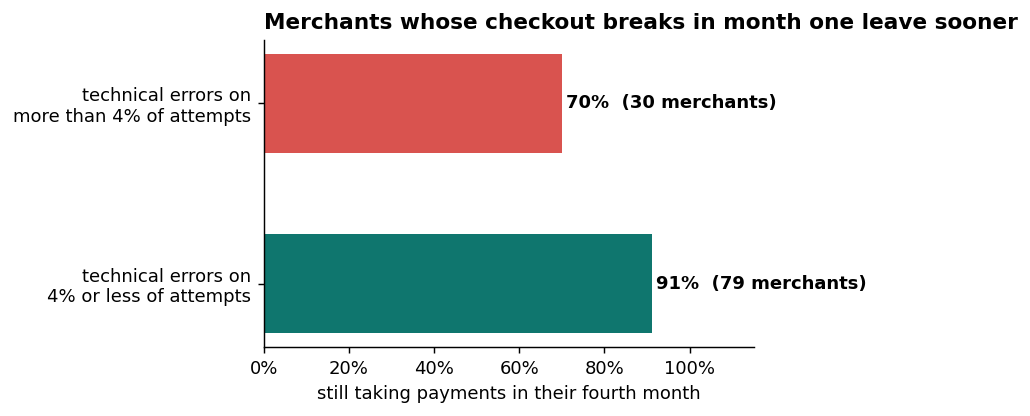

In [31]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
lk = link.loc[["4% or less", "above 4%"]]
ax.barh(["technical errors on\n4% or less of attempts", "technical errors on\nmore than 4% of attempts"], lk.active_month_3_pct, color=[TEAL, RED], height=.55)
for i, (v, n_) in enumerate(zip(lk.active_month_3_pct, lk.merchants)):
    ax.text(v + 1, i, f"{v:.0f}%  ({n_} merchants)", va="center", fontweight="bold")
ax.set_xlim(0, 115); ax.xaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlabel("still taking payments in their fourth month")
ax.set_title("Merchants whose checkout breaks in month one leave sooner")
fig.tight_layout(); fig.savefig(f"{CHARTS}/04_integration_and_retention.png", bbox_inches="tight"); plt.show()

Merchants whose checkout threw technical errors on more than 4% of attempts in their first month were much less likely to still be taking payments three months later (70% against 91%). It's a small group (30 merchants), so the number is rough. And it isn't proof of cause: a merchant with a badly built checkout may also be less committed to its business, and both would show up the same way. An onboarding check on technical errors in the first two weeks would be cheap and would test the link directly.

### 4.4 Ten merchants to call this week

In [32]:
recent = succ[succ.created_at >= "2026-07-01"].groupby([succ.merchant_id, succ.month]).amount.sum().unstack()
trend = (recent.get(pd.Period("2026-08", "M")) / recent.get(pd.Period("2026-07", "M")) - 1) * 100
calls = pd.DataFrame({"TPV Jul–Aug ₹ L": recent.sum(axis=1) / 1e5, "Aug vs Jul %": trend})
calls = calls.join(te[["tech_error_pct"]]).join(mer.set_index("merchant_id")[["category", "size_tier", "kyc_status"]])
calls["card fees ₹0 since May"] = calls.index.isin(fee_bad.merchant_id)
calls["Nilgiri late payouts"] = calls.index.map(nil_late.groupby("merchant_id").size()).fillna(0)
def why(r_):
    w = []
    if r_["Aug vs Jul %"] < -40: w.append(f"volume down {-r_['Aug vs Jul %']:.0f}% in August")
    if r_.tech_error_pct > 4: w.append(f"{r_.tech_error_pct:.0f}% of attempts hit technical errors")
    if r_.kyc_status == "on_hold": w.append("KYC hold: payouts stopped")
    if r_["Nilgiri late payouts"] > 150: w.append(f"{r_['Nilgiri late payouts']:.0f} payouts late via Nilgiri Bank")
    return "; ".join(w)
calls["why"] = calls.apply(why, axis=1)
calls["score"] = calls["TPV Jul–Aug ₹ L"] * ((calls["Aug vs Jul %"] < -40).astype(int) * 2 + (calls.tech_error_pct > 4).astype(int) * 2
                                             + (calls.kyc_status == "on_hold").astype(int) + (calls["Nilgiri late payouts"] > 150).astype(int))
call_list = calls[calls.why != ""].sort_values("score", ascending=False).head(10)
call_list[["category", "size_tier", "TPV Jul–Aug ₹ L", "Aug vs Jul %", "why"]].round(1)

,category,size_tier,TPV Jul–Aug ₹ L,Aug vs Jul %,why
merchant_id,,,,,
M11769,Education,Enterprise,194.60,-33.00,8% of attempts hit technical errors; 191 payou...
M10042,Travel,Enterprise,207.20,-0.90,167 payouts late via Nilgiri Bank
M11217,Education,Enterprise,187.70,-26.50,191 payouts late via Nilgiri Bank
M10493,Education,Enterprise,142.30,-33.30,152 payouts late via Nilgiri Bank
M10931,E-commerce,Enterprise,69.00,10.80,323 payouts late via Nilgiri Bank
M10577,E-commerce,Enterprise,46.80,16.70,223 payouts late via Nilgiri Bank
M10022,E-commerce,Enterprise,46.50,8.70,199 payouts late via Nilgiri Bank
M10107,Healthcare,Enterprise,43.90,-3.00,170 payouts late via Nilgiri Bank
M10211,E-commerce,Enterprise,34.20,2.70,154 payouts late via Nilgiri Bank


Each merchant is scored by how much money it brings and how many warning signs it shows: a sharp drop in August volume, a failing checkout, a KYC hold, or many late payouts through Nilgiri Bank. The list is mostly large merchants hit hardest by the Nilgiri delays, plus two whose checkout is failing. The ₹0 card-fee merchants aren't on it on purpose: that call is for finance and sales to make once the promise question is answered.

## Part 5 · One engineering sprint

In [33]:
fee_month = fees[fees.month >= "2026-05"].groupby("month").fee_charged.sum().mean()
options = pd.DataFrame([
    ["A · Fix Nilgiri Bank status integration", f"≈₹{per_month.loc['2026-05':].mean() / 1e5:.0f} lakh of payouts a month reach {nil_late.merchant_id.nunique()} merchants a working day late",
     "No direct revenue; merchant trust and support load. Churn effect not visible in this data", "Medium: needs the bank to change its side too"],
    ["B · Fix Growth-plan card pricing and recover fees", f"{inr(leak.fees_not_charged.mean())} of fees a month, plus {inr(leak.fees_not_charged.sum())} already missed",
     f"{100 * leak.fees_not_charged.mean() / fee_month:.1f}% of monthly fee revenue, recurring until fixed", "High: calculated payment by payment"],
    ["C · Daily automated reconciliation", "Would have caught B in days, the June ledger gap and the July failed-but-paid payments",
     "Prevents future losses; value depends on how often problems happen", "Low to medium: benefit is a forecast"],
], columns=["option", "₹ at stake", "what it means", "confidence"])
options

,option,₹ at stake,what it means,confidence
0,A · Fix Nilgiri Bank status integration,≈₹45 lakh of payouts a month reach 773 merchan...,No direct revenue; merchant trust and support ...,Medium: needs the bank to change its side too
1,B · Fix Growth-plan card pricing and recover fees,"₹42,213 of fees a month, plus ₹168,853 already...","5.9% of monthly fee revenue, recurring until f...",High: calculated payment by payment
2,C · Daily automated reconciliation,"Would have caught B in days, the June ledger g...",Prevents future losses; value depends on how o...,Low to medium: benefit is a forecast


**Recommendation: option B.** It's the only option with a direct, recurring revenue loss, it's measured exactly rather than estimated, and every month it waits costs about ₹42,000 more. It should also be small: a configuration fix and a recovery run, which leaves room in the sprint to start C.

**What would change this recommendation:** if sales promised these 85 merchants 0% on cards, the "leak" is a pricing decision, recovery is impossible, and B's value drops to zero. Or if merchants hit by Nilgiri's late payouts start leaving: A protects about ₹45 lakh a month of payouts, mostly to large merchants, and losing even one of them would cost more than B recovers.

**Headline number: ₹1.69 lakh of card fees not charged since 1 May.** It's in rupees, it's exact, it has one cause and one owner, and it grows by about ₹42,000 every month the fix waits.

**Metric for the investor deck: net take rate, shown next to UPI share.** TPV rewards volume that earns nothing, since two-thirds of it is UPI at 0%; success rate is an operations number investors can't connect to money. Net take rate is the only one of the three that links volume to revenue, and it's the one that would have exposed the ₹0 card fees in May. Shown next to UPI share, the fall that comes from UPI growth is easy to see and separate from a real problem.

## Part 6 · One chart for the Head of Payments

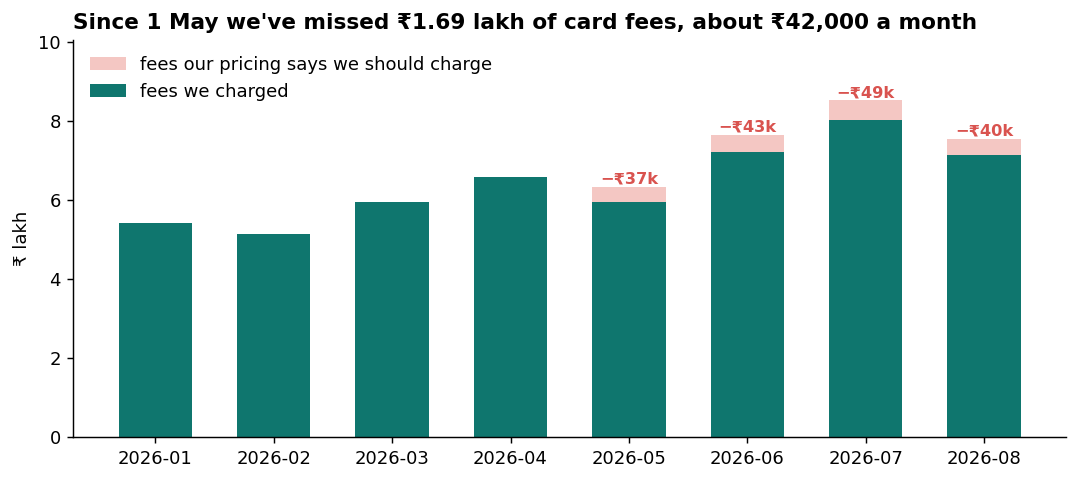

In [34]:
from IPython.display import Image, display
display(Image(f"{CHARTS}/00_recommendation.png", width=760))

**Fix the Growth-plan card pricing now: every month it waits costs about ₹42,000.**

## Part 7 · AI usage
How AI tools were used in this project, the most useful prompt, and what the model got wrong, are documented in `AI_USAGE.md` in the project root.

## Results used in the memo

In [35]:
out = {
    "order_success": float(monthly["success rate, orders %"].mean()), "attempt_success": float(monthly["success rate, attempts %"].mean()),
    "tpv_cr_total": float(monthly["TPV ₹ Cr"].sum()), "tpv_aug_cr": float(monthly["TPV ₹ Cr"].iloc[-1]),
    "take_jan": float(tr["take rate, all %"].iloc[0]), "take_aug": float(tr["take rate, all %"].iloc[-1]),
    "upi_jan": float(tr["UPI share of TPV %"].iloc[0]), "upi_aug": float(tr["UPI share of TPV %"].iloc[-1]),
    "leak_total": float(leak.fees_not_charged.sum()), "leak_month": float(leak.fees_not_charged.mean()),
    "leak_share": float(100 * leak.fees_not_charged.sum() / fees[fees.month >= "2026-05"].fee_charged.sum()),
    "leak_merchants": int(fee_bad.merchant_id.nunique()), "leak_payments": int(len(fee_bad)),
    "ledger_gap": float(miss.fee_charged.sum()), "ledger_batches": int(len(miss)),
    "fbs_n": int(len(fbs)), "fbs_value": float(fbs.payment_amount.sum()),
    "spike_n": int(len(spike)), "spike_value": float(spike.refund_amount.sum()),
    "nil_month": float(per_month.loc["2026-05":].mean()), "nil_merchants": int(nil_late.merchant_id.nunique()),
    "on_time_before": float(chain["on-time settlement %"].iloc[:4].mean()), "on_time_after": float(chain["on-time settlement %"].iloc[4:].mean()), "late_cutoff": int((late.cause.str.startswith("Payment")).sum()), "late_nil": int((late.cause.str.startswith("Nilgiri")).sum()), "other_banks_late_after_may": float(bank_late.drop("Nilgiri Bank").late_pct.mean()), "nil_late_after_may": float(bank_late.loc["Nilgiri Bank", "late_pct"]), "kyc_payments": int(gap.loc["Merchant on KYC hold", "payments"]), "kyc_merchants": int(gap.loc["Merchant on KYC hold", "merchants"]), "kyc_value": float(gap.loc["Merchant on KYC hold", "value"]),
    "konkan_peak": float(nb.loc["Konkan Bank", "7–11 pm"]), "other_peak": float(nb.drop("Konkan Bank")["7–11 pm"].mean()),
    "top10_tpv": float(100 * mv.tpv.nlargest(k).sum() / mv.tpv.sum()),
    "link": link.round(1).reset_index().to_dict("records"),
    "log": log.to_dict("records"),
    "gap": gap.reset_index().assign(value=lambda d: d.value.astype(float)).to_dict("records"),
    "customer_fail_share": float(reason.loc[["customer_dropped", "insufficient_funds"], "% of failed attempts"].sum()),
}
json.dump(out, open("../reports/results.json", "w"), indent=1, default=str)
print(json.dumps({k_: v for k_, v in out.items() if not isinstance(v, list)}, indent=1))

{
 "order_success": 93.33985120478846,
 "attempt_success": 88.77706051441018,
 "tpv_cr_total": 101.1689305,
 "tpv_aug_cr": 17.0042417,
 "take_jan": 0.6130436529375676,
 "take_aug": 0.43714541658235206,
 "upi_jan": 56.8052475050177,
 "upi_aug": 67.2858672700721,
 "leak_total": 168852.79,
 "leak_month": 42213.1975,
 "leak_share": 5.945839882012259,
 "leak_merchants": 85,
 "leak_payments": 3937,
 "ledger_gap": 74910.04,
 "ledger_batches": 1177,
 "fbs_n": 184,
 "fbs_value": 476792.0,
 "spike_n": 1663,
 "spike_value": 1860297.0,
 "nil_month": 4505387.5,
 "nil_merchants": 773,
 "on_time_before": 97.40306990628088,
 "on_time_after": 94.32889072412829,
 "late_cutoff": 11253,
 "late_nil": 7781,
 "other_banks_late_after_may": 2.866643295276596,
 "nil_late_after_may": 26.26748251748252,
 "kyc_payments": 738,
 "kyc_merchants": 26,
 "kyc_value": 1344495.0,
 "konkan_peak": 39.9,
 "other_peak": 17.942857142857143,
 "top10_tpv": 83.09778638531786,
 "customer_fail_share": 61.3
}
